In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/perf_dal /home/dhuseljic/mlflow

import os 
import json
import mlflow
import torch
import matplotlib
import numpy as np
import pylab as plt

from pathlib import Path
from datetime import datetime

os.makedirs('plots', exist_ok=True)
matplotlib.rcParams['figure.figsize'] = (4, 3)
torch.set_grad_enabled(False)

def filter_by_date(runs, year, month, day, hour=0, min=0, fn=np.greater):
    filtered_runs = []
    for run in runs:
        start_time = datetime.fromtimestamp(run.info.start_time / 1000) # in ms
        filter_time = datetime(year, month, day, hour, min)
        if fn(start_time, filter_time):
            filtered_runs.append(run)
    return filtered_runs

def rename_parameter(run, param_name, name):
    run.data.params[param_name] = name
    return run


def download_artifacts(run, to_path=Path.home() / 'server_artifacts'):
    global_uri = Path(run.info.artifact_uri)
    local_uri = Path(*global_uri.parts[-4:])
    dest = to_path / local_uri
    os.makedirs(dest, exist_ok=True)
    print(f'Downloading artifacts from {global_uri} to {dest}')
    os.system(f'rsync -avz cluster.ies:{global_uri}/ {dest}')
    return dest

def get_runs(uri, exp_name, query_list):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    if len(runs) == 0:
        print('No runs found.')
    return runs


receiving incremental file list
perf_dal/
perf_dal/oracle.db

sent 91,821 bytes  received 2,088,911 bytes  484,607.11 bytes/sec
total size is 249,319,424  speedup is 114.33


In [2]:
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'

experiments = {
    'cifar10': {
        'random': lambda: get_runs(uri, 'oracle_v2', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'random'"]),
        'cross_domain_oracle': lambda: get_runs(uri, 'oracle_v2', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, 'oracle_v13', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    },
    'dtd': {
        'random': lambda: get_runs(uri, 'oracle_v15', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'random'"]),
        'cross_domain_oracle': lambda: get_runs(uri, 'oracle_v2', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, 'oracle_v13', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'perf_dal_oracle'"]),
        'perf_dal_oracle2': lambda: get_runs(uri, 'oracle_v15', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    },
    'cifar100': {
        'random': lambda: get_runs(uri, 'oracle_v2', ["parameter.dataset_name = 'cifar100'", "parameter.al.strategy = 'random'"]),
        'cross_domain_oracle': lambda: get_runs(uri, 'oracle_v2', ["parameter.dataset_name = 'cifar100'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, 'oracle_v13', ["parameter.dataset_name = 'cifar100'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    } 
}

In [4]:
from collections import defaultdict

uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'
dataset = 'dtd'
init_query_list = [f"parameter.dataset_name = '{dataset}'"]

runs = []
runs_ = experiments[dataset]['random']()
runs.extend(runs_)

runs_ = experiments[dataset]['perf_dal_oracle2']()
runs_ = [rename_parameter(run, 'al.strategy', 'perf_dal_oracle') for run in runs_]
runs.extend(runs_)

runs_ = experiments[dataset]['cross_domain_oracle']()
runs_ = [rename_parameter(run, 'al.strategy', 'cross_domain_oracle') for run in runs_]
runs.extend(runs_)

print('Found {} experiments'.format(len(runs)))

runs_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs:
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves_strategies:
    print(f"{key:10}: {len(acc_curves_strategies[key]):3}")

Found 60 experiments
random    :  20
perf_dal_oracle:  20
cross_domain_oracle:  20


In [5]:
acc_curves_random = acc_curves_strategies['random']
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)
axis_single = np.arange(acq_size, (acq_size*(num_acq+1))+1, 1)

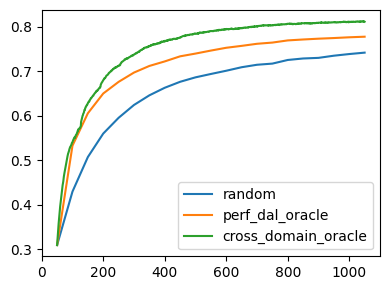

In [6]:
plt.figure(figsize=(4, 3))

for key in acc_curves_strategies:
    try:
        plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), label=key)
    except:
        plt.plot(axis_single, np.mean(acc_curves_strategies[key], axis=0), label=key)

plt.tight_layout()
plt.legend()

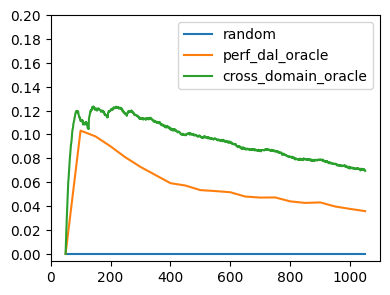

In [7]:
plt.figure(figsize=(4, 3))

acc_random = np.mean(acc_curves_random, axis=0)
for key in acc_curves_strategies:
    try:
        plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - acc_random , label=key)
    except:
        acc_random_interp = np.interp(axis_single, axis, acc_random)
        plt.plot(axis_single, np.mean(acc_curves_strategies[key]- acc_random_interp, axis=0), label=key)

plt.tight_layout()

plt.yticks(np.linspace(0, 0.2, 11))
plt.legend()

## How does an optimal strategy select batches?

In [235]:
bought_dict = defaultdict(list)
for run in runs_per_strat['perf_dal_oracle']:
    for key in run.data.metrics.keys():
        if 'bought' in key:
            bought_metric = [m.value for m in client.get_metric_history(run.info.run_id, key)]
            bought_dict[key.split('_')[-1]].append(bought_metric)

In [236]:
buy_mat_dict = {}
for key in bought_dict:
    accumulative_buy_mat = np.array(bought_dict[key])
    buy_mat = accumulative_buy_mat[:, 1:] - accumulative_buy_mat[:, :-1]
    buy_mat_dict[key] = np.mean(buy_mat, axis=0)
buy_matrices = np.stack([buy_mat_dict[key] for key in buy_mat_dict])

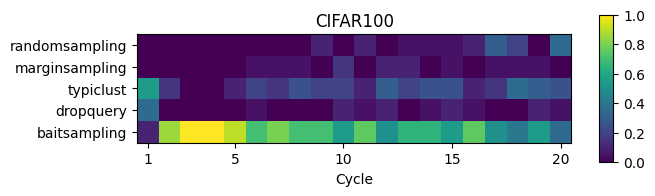

In [237]:
plt.figure(figsize=(7, 7))
plt.title(dataset.upper())
plt.imshow(buy_matrices, vmin=0, vmax=1)
plt.yticks(range(len(buy_mat_dict)), buy_mat_dict.keys())
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('Cycle')
plt.colorbar(location='right', shrink=.22, aspect=10)
plt.tight_layout()
plt.savefig(f'plots/{dataset}_bought_per_cycle.pdf', bbox_inches='tight')
plt.show()

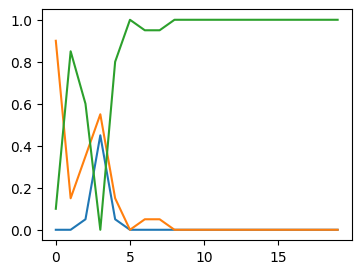

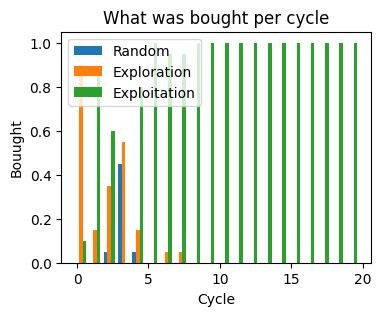

In [12]:
buy_matrix_mean = np.mean(buy_matrix, axis=0)
bought_random_mean = buy_matrix_mean[:, 0]
bought_diverse_mean = buy_matrix_mean[:, 1]
bought_uncertain_mean = buy_matrix_mean[:, 2]
labels = ['Random', 'Exploration', 'Exploitation']

plt.plot(bought_random_mean )
plt.plot(bought_diverse_mean )
plt.plot(bought_uncertain_mean )
plt.show()

bar_width = 0.25  # Width of the bars
x = np.arange(len(bought_random_mean)) # Position of bars on x-axis
fig, ax = plt.subplots()
for i, vals in enumerate([bought_random_mean, bought_diverse_mean, bought_uncertain_mean]):
    ax.bar(x + i * bar_width, vals, width=bar_width, label=labels[i])

#zoom_ax = fig.add_axes([0.25, 0.5, 0.25, 0.35])  # (x_position, y_position, width, height)

# Adding value labels on top of each bar
# Set the labels
ax.set_xlabel('Cycle')
ax.set_ylabel('Bouught')
ax.set_title('What was bought per cycle')
ax.legend()
plt.show()


## Consider a single experiment

In [18]:
seed = 1
print(runs_per_strat.keys())
strat = 'perf_based_dal'
runs = [run for run in runs_per_strat[strat]]
runs = filter(lambda x: x.data.params['random_seed'] == f'{seed}', runs)
run = list(runs)[0]
artifact_path = download_artifacts(run)

with open(artifact_path / f'artifacts_cycle20', "r") as f:
    data = json.load(f)


dict_keys(['perf_based_dal', 'random', 'cross_domain_oracle'])
receiving incremental file list
./
artifacts_cycle00
artifacts_cycle01
artifacts_cycle02
artifacts_cycle03
artifacts_cycle04
artifacts_cycle05
artifacts_cycle06
artifacts_cycle07
artifacts_cycle08
artifacts_cycle09
artifacts_cycle10
artifacts_cycle11
artifacts_cycle12
artifacts_cycle13
artifacts_cycle14
artifacts_cycle15
artifacts_cycle16
artifacts_cycle17
artifacts_cycle18
artifacts_cycle19
artifacts_cycle20

sent 426 bytes  received 25,368 bytes  17,196.00 bytes/sec
total size is 1,337,411  speedup is 51.85


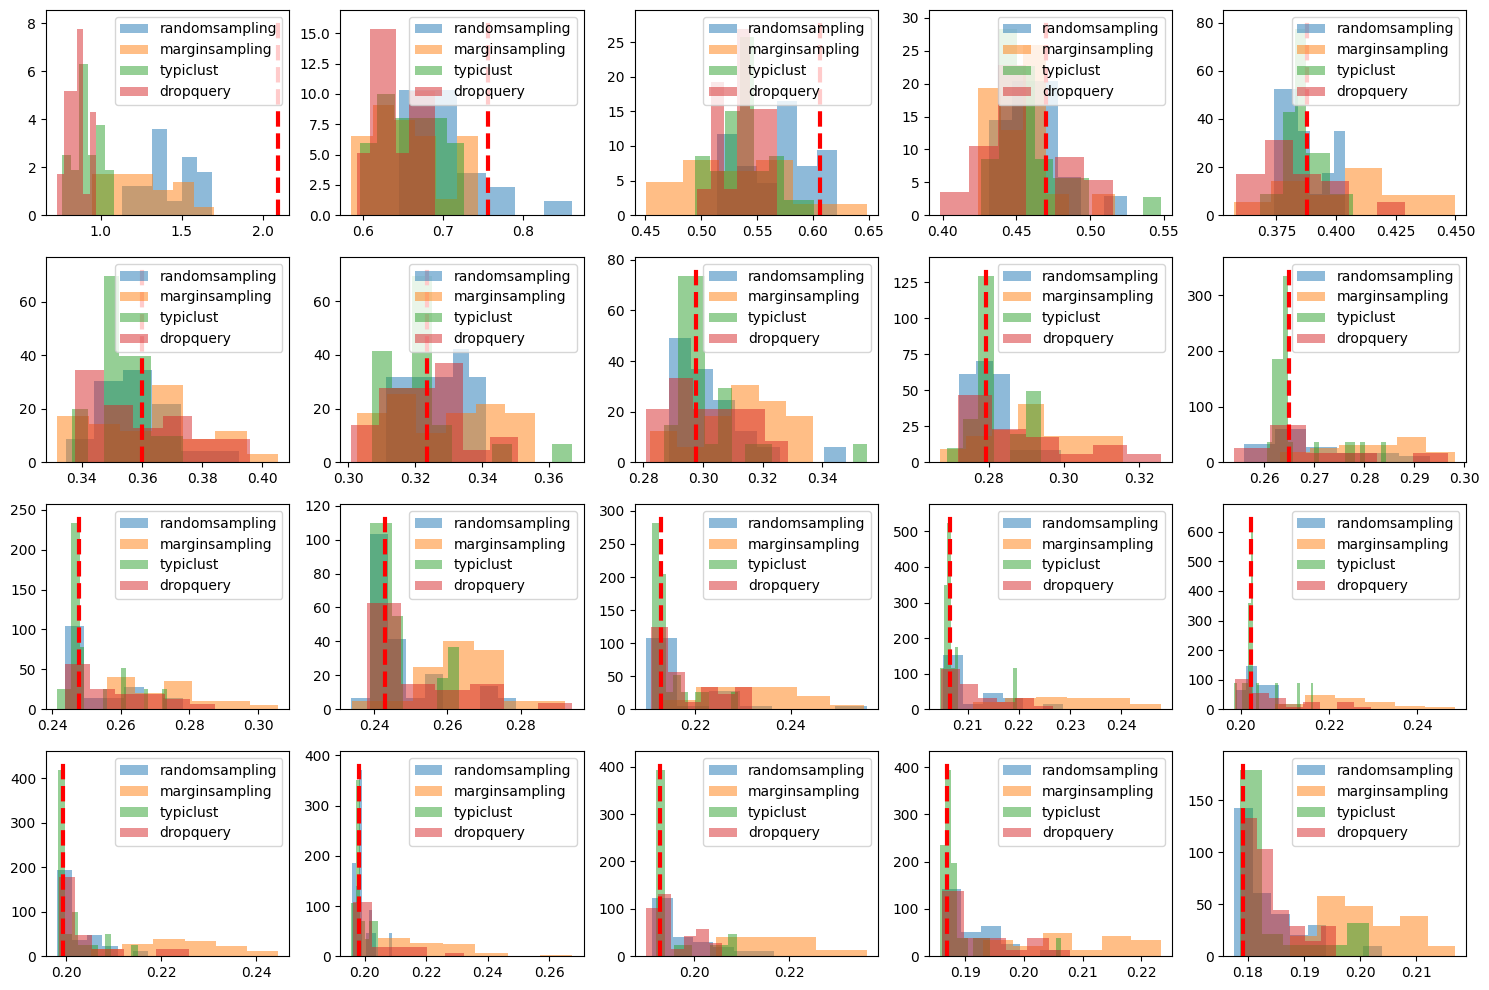

In [19]:
from copy import deepcopy
oracle_history = data['oracle_history']
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()
for i_cycle, d in enumerate(oracle_history):
    loss_batches = d['loss_batches']
    base_loss = d['base_loss']
    batches_counts = deepcopy(d['batches_counts'])

    # del batches_counts['random']
    # del batches_counts['diverse']
    # del batches_counts['uncertain']

    plt.sca(axes[i_cycle])
    losses_per_type = np.split(loss_batches, np.cumsum(list(batches_counts.values())[:-1]))
    for losses, type in zip(losses_per_type, batches_counts):
        plt.hist(losses, bins='auto', density=True, label=type, alpha=0.5)
    plt.vlines(base_loss, *plt.ylim(), colors='red', lw=3, ls='--')
    plt.legend()
plt.tight_layout()

In [184]:
import torch
import sys
import argparse
sys.path.append('..')
from utils import build_image_data
from dal_toolbox.utils import seed_everything
from torchvision.utils import make_grid

query_indices_dict = {}
model_weights_dict = {}
artifact_paths = sorted(list(artifact_path.glob('*')), key=lambda x: int(x.stem.lstrip('artifacts_cycle')))
for i_acq, a_path in enumerate(artifact_paths):
    with open(a_path, "r") as f:
        data = json.load(f)
    data['query_indices'] = [int(idx) for idx in data['query_indices']]
    query_indices_dict[i_acq] = data['query_indices']
    model_weights_dict[i_acq] = data['model']

args = argparse.Namespace(dataset_name=run.data.params['dataset_name'], dataset_path='/home/datasets')
seed_everything(42)
ds = build_image_data(args, plain_transforms=True)
query_ds = ds.train_dataset
query_indices = np.concat([query_indices_dict[i_acq] for i_acq in query_indices_dict])

Seed set to 42


In [185]:
from torch.utils.data import DataLoader
from dal_toolbox.datasets.utils import DinoTransforms
from dal_toolbox.utils import seed_everything
device ='cuda'

seed_everything(42)
tsne_indices = torch.arange(len(query_ds))
# tsne_indices = torch.randperm(len(query_ds))[:1000]
# tsne_indices = torch.cat((tsne_indices, torch.tensor(query_indices))).unique()

query_ds.dataset.transform = DinoTransforms(size=(256, 256)).transform
dl = DataLoader(query_ds, sampler=tsne_indices, batch_size=128)
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

features = []
labels = []
model.eval()
model.to(device)
for batch in dl:
    features.append(model(batch[0].to(device)).to('cpu'))
    labels.append(batch[-1])
features = torch.cat(features)
labels = torch.cat(labels)

Seed set to 42
Using cache found in /home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main


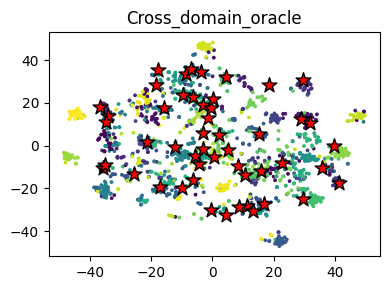

In [186]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42)
features_tsne = tsne.fit_transform(features)

plt.title(strat.capitalize())
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, s=3)
plt.scatter(features_tsne[query_indices[50:100], 0], features_tsne[query_indices[50:100], 1], c='red', s=125, marker='*', lw=1, ec='k')
plt.tight_layout()
# plt.savefig(f'plots/{dataset}_tsne_{strat}.pdf', bbox_inches='tight')


In [133]:
i_acq = 
query_indices = query_indices_dict[i_acq]
imgs = torch.stack([query_ds[idx][0] for idx in query_indices], dim=0)
labels = torch.Tensor([query_ds[idx][1] for idx in query_indices])
uniques, counts = labels.unique(return_counts=True)
print(f'Found {len(uniques)} classes')

img_grid = make_grid(imgs[:32], nrow=16)
plt.figure(figsize=(15, 5))
plt.imshow(img_grid.permute(1, 2, 0))
plt.show()

SyntaxError: invalid syntax (2397123550.py, line 1)

In [132]:
torch.stack([img for img, _ in query_ds]).shape

torch.Size([1692, 3, 224, 224])

In [3]:
from collections import defaultdict

exp_name = 'oracle_v4'
dataset = 'cifar10'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'

runs = []

query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'random'"]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_)

for subset_size in [100, 500, 1000, 5000, 10000, None]:
    query_list = [f"parameter.dataset_name = '{dataset}'", "parameter.al.strategy = 'perf_dal_oracle'", f"parameter.al.subset_size = '{subset_size}'"]
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs_ = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    runs_ = [rename_parameter(run, 'al.strategy', run.data.params['al.subset_size']) for run in runs_]
    runs.extend(runs_)


# runs1 = filter_by_date(runs, 2024, 11, 29, 13, 10, fn=np.less)
# runs2 = filter_by_date(runs, 2024, 11, 29, 15, 50)
# runs = runs1 + runs2

print('Found {} experiments'.format(len(runs)))


runs_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

acc_curves_random = acc_curves_strategies['random']

for key in  acc_curves_strategies:
    print(f"{key:10}: {len(acc_curves_strategies[key]):3}")

# run = runs_per_strat['optimal'][0]
# params = run.data.params
# {key: val for key, val in params.items() if key.startswith('al')}

Found 140 experiments
random    :  20
100       :  20
500       :  20
1000      :  20
5000      :  20
10000     :  20
None      :  20


In [6]:
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)
axis_single = np.arange(acq_size, (acq_size*(num_acq+1))+1, 1)

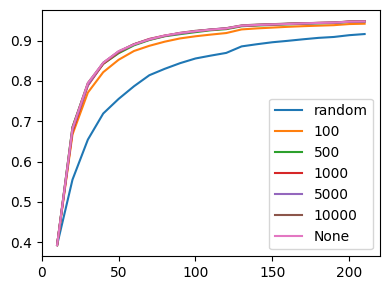

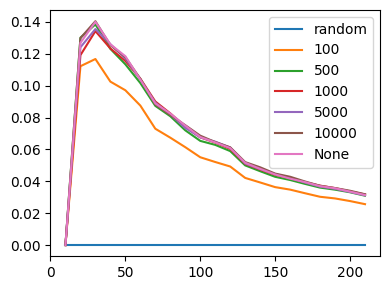

In [8]:
plt.figure(figsize=(4, 3))

for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), label=key)

plt.tight_layout()
plt.legend()

plt.figure(figsize=(4, 3))

acc_random = np.mean(acc_curves_random, axis=0)
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - acc_random , label=key)

plt.tight_layout()
plt.legend()

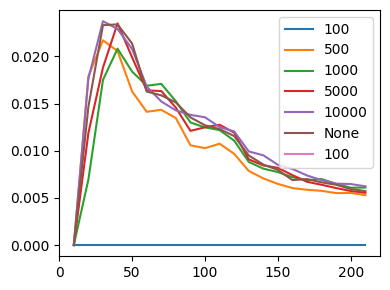

In [21]:
plt.figure(figsize=(4, 3))

base = np.mean(acc_curves_strategies['100'], axis=0)
for key in acc_curves_strategies:
    if key == 'random': continue
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - base, label=key)

plt.tight_layout()
plt.legend()

In [ ]:

base

[[0.38749998807907104,
  0.6837000250816345,
  0.7705000042915344,
  0.8266000151634216,
  0.8514000177383423,
  0.8705000281333923,
  0.8867999911308289,
  0.8992999792098999,
  0.9100000262260437,
  0.9153000116348267,
  0.9190000295639038,
  0.921999990940094,
  0.9269000291824341,
  0.9323999881744385,
  0.932699978351593,
  0.9351000189781189,
  0.9366000294685364,
  0.9390000104904175,
  0.939300000667572,
  0.9427000284194946,
  0.9416000247001648],
 [0.45260000228881836,
  0.7311999797821045,
  0.8027999997138977,
  0.8428000211715698,
  0.866599977016449,
  0.8798999786376953,
  0.8966000080108643,
  0.9079999923706055,
  0.9106000065803528,
  0.911899983882904,
  0.9156000018119812,
  0.9215999841690063,
  0.9280999898910522,
  0.9298999905586243,
  0.9332000017166138,
  0.9341999888420105,
  0.9355999827384949,
  0.9372000098228455,
  0.9383999705314636,
  0.9406999945640564,
  0.9415000081062317],
 [0.3483000099658966,
  0.7026000022888184,
  0.8001000285148621,
  0.8449000